In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F

if torch.backends.mps.is_available():
    device = torch.device('mps')
    print( f'you are using a Mac-based GPU' )
elif torch.cuda().is_available():
    device = torch.cuda.device(0)
    print( 'You are using a '+str(torch.cuda.get_device_name(0)) )
else: 
    device = torch.device('cpu')
    print( f'you are using a: {device}' )

you are using a Mac-based GPU


# CIFAR10
---

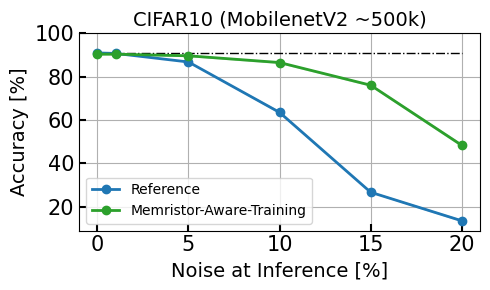

In [2]:
import pickle

dir_load = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results/CIFAR10_MobilenetV2.pkl'
dict_results = pickle.load( open(dir_load, 'rb') )

noise_sd_list = dict_results['noise_sd_list']
acc_test_vanilla = 100*dict_results['acc_test_c10_normal']
acc_test_vanilla_ref = 100*dict_results['acc_test_c10_normal'][:,0]
acc_test_mat = 100*dict_results['acc_test_c10_mat']

fig, ax = plt.subplots( figsize=(5,3) )
# reference accuracy w/out noise
ax.hlines( np.mean( acc_test_vanilla_ref, axis=0 ), noise_sd_list[0]*100, noise_sd_list[-1]*100, lw=1, linestyle='-.', color='k')
# vanilla training
ax.plot( 100*noise_sd_list, np.mean( acc_test_vanilla, axis=0 ), lw=2, marker='o', ms=6, label='Reference')
ax.fill_between( 100*noise_sd_list, np.quantile( acc_test_vanilla, axis=0, q=0.5-0.38 ), np.quantile( acc_test_vanilla, axis=0, q=0.5+0.38 ), alpha=0.3 )
# with the noise in forward phase
ax.plot( 100*noise_sd_list, np.mean( acc_test_mat, axis=0 ), lw=2, marker='o', ms=6, label='Memristor-Aware-Training', color='tab:green')
ax.fill_between( 100*noise_sd_list, np.quantile( acc_test_mat, axis=0, q=0.5-0.38 ), np.quantile( acc_test_mat, axis=0, q=0.5+0.38 ), alpha=0.3, color='tab:green' )
ax.tick_params( which='major', labelsize=15, direction='in', size=5, width=1.5 )
ax.tick_params( which='minor', direction='in', size=2.5 )
#ax.set_xscale('log')
ax.set_yticks( np.arange( 20,110,20 ) )
ax.set_title('CIFAR10 (MobilenetV2 ~500k)', size=14)
ax.set_xlabel('Noise at Inference [%]', size=14)
ax.set_ylabel('Accuracy [%]', size=14)
ax.grid()
ax.legend( prop={'size':10} )

## saving the plot
plt.tight_layout()
root_path_results = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results'
file_save_plot = root_path_results + '/CIFAR10_MAT_b.pdf'
# fig.savefig( file_save_plot, dpi=300, transparent=True )

# CIFAR100
---

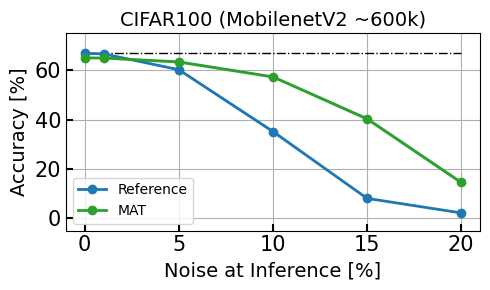

In [3]:
import pickle

dir_load = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results/CIFAR100_MobilenetV2.pkl'
dict_results = pickle.load( open(dir_load, 'rb') )

noise_sd_list = dict_results['noise_sd_list']
acc_test_vanilla = 100*dict_results['acc_test_c100_normal']
acc_test_vanilla_ref = 100*dict_results['acc_test_c100_normal'][:,0]
acc_test_mat = 100*dict_results['acc_test_c100_mat']

fig, ax = plt.subplots( figsize=(5,3) )
# reference accuracy w/out noise
ax.hlines( np.mean( acc_test_vanilla_ref, axis=0 ), noise_sd_list[0]*100, noise_sd_list[-1]*100, lw=1, linestyle='-.', color='k')
# vanilla training
ax.plot( 100*noise_sd_list, np.mean( acc_test_vanilla, axis=0 ), lw=2, marker='o', ms=6, label='Reference')
ax.fill_between( 100*noise_sd_list, np.quantile( acc_test_vanilla, axis=0, q=0.5-0.38 ), np.quantile( acc_test_vanilla, axis=0, q=0.5+0.38 ), alpha=0.3 )
# with the noise in forward phase
ax.plot( 100*noise_sd_list, np.mean( acc_test_mat, axis=0 ), lw=2, marker='o', ms=6, label='MAT', color='tab:green')
ax.fill_between( 100*noise_sd_list, np.quantile( acc_test_mat, axis=0, q=0.5-0.38 ), np.quantile( acc_test_mat, axis=0, q=0.5+0.38 ), alpha=0.3, color='tab:green' )
ax.tick_params( which='major', labelsize=15, direction='in', size=5, width=1.5 )
ax.tick_params( which='minor', direction='in', size=2.5 )
#ax.set_xscale('log')
ax.set_yticks( np.arange( 0,80,20 ) )
ax.set_ylim( -5, 75 )
ax.set_title('CIFAR100 (MobilenetV2 ~600k)', size=14)
ax.set_xlabel('Noise at Inference [%]', size=14)
ax.set_ylabel('Accuracy [%]', size=14)
ax.grid()
ax.legend( prop={'size':10}, loc=3 )

## saving the plot
plt.tight_layout()
root_path_results = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results'
file_save_plot = root_path_results + '/CIFAR100_MAT.png'
# fig.savefig( file_save_plot, dpi=300, transparent=True )


# MNIST
---

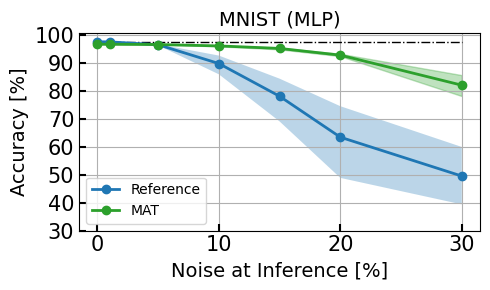

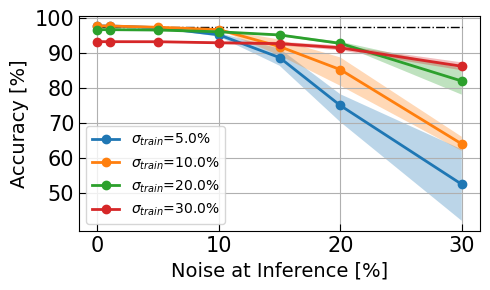

In [5]:
import pickle
dir_vanilla = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results/Vanilla_MNIST_MLP_new.pkl'
with open(dir_vanilla, 'rb') as file_handler:
    dict_results_vanilla = pickle.load( file_handler )
dir_NoiseBack = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results/NoiseBack_MNIST_MLP_new.pkl'
with open(dir_NoiseBack, 'rb') as file_handler:
    dict_results_NoiseBack = pickle.load( file_handler )


noise_sd_list = dict_results_vanilla['noise_sd_list']
acc_test_vanilla = 100*dict_results_vanilla['acc_test_vanilla']
acc_test_vanilla_ref = 100*dict_results_vanilla['acc_test_vanilla_ref']
acc_test_nudging = 100*dict_results_NoiseBack['acc_test_nudging']
acc_test_nudging_ref = 100*dict_results_NoiseBack['acc_test_nudging_ref']
acc_test_fon = 100*dict_results_NoiseForw['acc_test_fon']

fig, ax = plt.subplots( figsize=(5,3) )
# reference accuracy w/out noise
ax.hlines( np.mean( acc_test_vanilla_ref, axis=0 ), noise_sd_list[0]*100, noise_sd_list[-1]*100, lw=1, linestyle='-.', color='k')
# vanilla training
ax.plot( 100*noise_sd_list, np.mean( acc_test_vanilla, axis=0 ), lw=2, marker='o', ms=6, label='Reference')
ax.fill_between( 100*noise_sd_list, np.quantile( acc_test_vanilla, axis=0, q=0.5-0.38 ), np.quantile( acc_test_vanilla, axis=0, q=0.5+0.38 ), alpha=0.3 )
# with the noise in forward phase
ax.plot( 100*noise_sd_list, np.mean( acc_test_fon, axis=0 ), lw=2, marker='o', ms=6, label='MAT', color='tab:green')
ax.fill_between( 100*noise_sd_list, np.quantile( acc_test_fon, axis=0, q=0.5-0.38 ), np.quantile( acc_test_fon, axis=0, q=0.5+0.38 ), alpha=0.3, color='tab:green' )
ax.tick_params( which='major', labelsize=15, direction='in', size=5, width=1.5 )
ax.tick_params( which='minor', direction='in', size=2.5 )
#ax.set_xscale('log')
ax.set_yticks( np.arange( 30,110,10 ) )
ax.set_title('MNIST (MLP)', size=14)
ax.set_xlabel('Noise at Inference [%]', size=14)
ax.set_ylabel('Accuracy [%]', size=14)
ax.grid()
ax.legend( prop={'size':10} )

## saving the plot
plt.tight_layout()
root_path_results = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results'
file_save_plot = root_path_results + '/MNIST_MAT.png'
# fig.savefig( file_save_plot, dpi=300, transparent=True )



noise_sd_train_list = np.array( [0.05, 0.1, 0.2, 0.3] )
accuracy_ste = []
for n, noise_sd in enumerate(noise_sd_train_list):
    dir_NoiseForw = f'/Users/filippomoro/Documents/Memristor-Aware-Training/Results/NoiseForw_MNIST_MLP_new_{noise_sd}.pkl'
    with open(dir_NoiseForw, 'rb') as file_handler:
        dict_results_NoiseForw = pickle.load( file_handler )
        accuracy_ste.append( 100*dict_results_NoiseForw['acc_test_fon'] )
accuracy_ste = np.stack(accuracy_ste)



fig, ax = plt.subplots( figsize=(5,3) )
# reference accuracy w/out noise
ax.hlines( np.mean( acc_test_vanilla_ref, axis=0 ), noise_sd_list[0]*100, noise_sd_list[-1]*100, lw=1, linestyle='-.', color='k')
# with the noise in forward phase
for n, noise_sd in enumerate(noise_sd_train_list):
    ax.plot( 100*noise_sd_list, np.mean( accuracy_ste[n], axis=0 ), lw=2, marker='o', ms=6, label=r'$\sigma_{train}$='+str(noise_sd*100)+'%')
    ax.fill_between( 100*noise_sd_list, np.quantile( accuracy_ste[n], axis=0, q=0.5-0.38 ), np.quantile( accuracy_ste[n], axis=0, q=0.5+0.38 ), alpha=0.3 )
ax.tick_params( which='major', labelsize=15, direction='in', size=5 )
ax.tick_params( which='minor', direction='in', size=2.5 )
#ax.set_xscale('log')
ax.set_yticks( np.arange( 50,110,10 ) )
ax.set_xlabel('Noise at Inference [%]', size=14)
ax.set_ylabel('Accuracy [%]', size=14)
ax.grid()
ax.legend( prop={'size':10} )

## saving the plot
plt.tight_layout()
root_path_results = '/Users/filippomoro/Documents/Memristor-Aware-Training/Results'
file_save_plot = root_path_results + '/MNIST_noise_at_inference_2.pdf'
# fig.savefig( file_save_plot, dpi=300, transparent=True )